In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [75]:
df  = pd.read_csv("../artifacts/raw/data.csv")
df


,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2024-03-10 10:35:00,3,Idle,71.143556,1.861171,2.897206,11.967279,4.670305,2.823803,282.822791,0.133871,12.631304,Low
99996,2024-03-10 10:36:00,23,Idle,77.256970,0.377495,5.037060,39.687650,3.996942,6.065958,466.696532,0.775575,2.292894,Medium
99997,2024-03-10 10:37:00,10,Active,52.800333,2.629977,3.900503,26.721615,4.821022,5.090971,324.277200,0.151740,6.315872,Low
99998,2024-03-10 10:38:00,47,Active,79.967251,2.283934,7.156484,9.534678,0.481175,8.333964,65.965864,0.989501,4.802397,Low


In [64]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ====================================================================
# CONFIGURATION
# ====================================================================
RANDOM_STATE = 42
TEST_SIZE = 0.2

print("="*70)
print("PIPELINE ML COMPLET - PREDICTIVE MAINTENANCE")
print("="*70)

# ====================================================================
# ÉTAPE 1: CHARGEMENT DES DONNÉES
# ====================================================================
print("\n[ÉTAPE 1] CHARGEMENT DES DONNÉES")
print("-"*70)
 # REMPLACER PAR VOTRE FICHIER

print(f"✓ Données chargées: {df.shape}")
print(f"\nAperçu des données:")
print(df.head())

print(f"\nTypes de colonnes:")
print(df.dtypes)

print(f"\nValeurs manquantes:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ Aucune valeur manquante")

PIPELINE ML COMPLET - PREDICTIVE MAINTENANCE

[ÉTAPE 1] CHARGEMENT DES DONNÉES
----------------------------------------------------------------------
✓ Données chargées: (100000, 13)

Aperçu des données:
             Timestamp  Machine_ID Operation_Mode  Temperature_C  \
0  2024-01-01 00:00:00          39           Idle      74.137590   
1  2024-01-01 00:01:00          29         Active      84.264558   
2  2024-01-01 00:02:00          15         Active      44.280102   
3  2024-01-01 00:03:00          43         Active      40.568502   
4  2024-01-01 00:04:00           8           Idle      75.063817   

   Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  Packet_Loss_%  \
0      3.500595              8.612162           10.650542       0.207764   
1      3.355928              2.268559           29.111810       2.228464   
2      2.079766              6.144105           18.357292       1.639416   
3      0.298238              4.067825           29.153629       1.161021   
4      

In [65]:

# ====================================================================
# ÉTAPE 2: ANALYSE DE LA TARGET
# ====================================================================
print("\n[ÉTAPE 2] ANALYSE DE LA VARIABLE CIBLE")
print("-"*70)

print("\nDistribution de Efficiency_Status:")
print(df['Efficiency_Status'].value_counts().sort_index())

print("\nPourcentages:")
target_dist = df['Efficiency_Status'].value_counts(normalize=True) * 100
print(target_dist.sort_index())

# Calculer le ratio de déséquilibre
min_class = df['Efficiency_Status'].value_counts().min()
max_class = df['Efficiency_Status'].value_counts().max()
imbalance_ratio = max_class / min_class

print(f"\nRatio de déséquilibre: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("Classes déséquilibrées détectées")
    print("➜ Utilisation de class_weight='balanced' recommandée")


[ÉTAPE 2] ANALYSE DE LA VARIABLE CIBLE
----------------------------------------------------------------------

Distribution de Efficiency_Status:
Efficiency_Status
High       2986
Low       77825
Medium    19189
Name: count, dtype: int64

Pourcentages:
Efficiency_Status
High       2.986
Low       77.825
Medium    19.189
Name: proportion, dtype: float64

Ratio de déséquilibre: 26.06:1
Classes déséquilibrées détectées
➜ Utilisation de class_weight='balanced' recommandée


In [66]:

# ====================================================================
# ÉTAPE 3: SÉLECTION ET PRÉPARATION DES FEATURES
# ====================================================================
print("\n[ÉTAPE 3] SÉLECTION DES FEATURES")
print("-"*70)

# Colonnes à exclure (critères stricts)
EXCLUDE_COLUMNS = [
    'Timestamp',                    # Temporel, pas une feature
    'Efficiency_Status'             # Target
]

# Optionnel: exclure aussi des colonnes qui pourraient leak
# Décommenter si besoin après analyse
# EXCLUDE_COLUMNS.extend([
#     'Predictive_Maintenance_Score',  # Peut être calculé à partir de la target
#     'Quality_Control_Defect_Rate_%', # Peut être corrélé à la target
# ])

# Sélectionner les features
feature_cols = [col for col in df.columns if col not in EXCLUDE_COLUMNS]

print(f"✓ {len(feature_cols)} features sélectionnées:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Vérifier s'il y a des colonnes non-numériques
X = df[feature_cols].copy()
y = df['Efficiency_Status'].copy()

# Identifier les colonnes non-numériques
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric) > 0:
    print(f"\n⚠️ Colonnes non-numériques détectées: {non_numeric}")
    print("Ces colonnes seront converties ou supprimées")
    
    # Pour l'exemple, on les supprime
    # Vous pouvez faire du encoding si nécessaire
    X = X.select_dtypes(include=[np.number])
    feature_cols = X.columns.tolist()
    print(f"✓ Features numériques restantes: {len(feature_cols)}")

print(f"\nShape final de X: {X.shape}")
print(f"Shape final de y: {y.shape}")



[ÉTAPE 3] SÉLECTION DES FEATURES
----------------------------------------------------------------------
✓ 11 features sélectionnées:
  1. Machine_ID
  2. Operation_Mode
  3. Temperature_C
  4. Vibration_Hz
  5. Power_Consumption_kW
  6. Network_Latency_ms
  7. Packet_Loss_%
  8. Quality_Control_Defect_Rate_%
  9. Production_Speed_units_per_hr
  10. Predictive_Maintenance_Score
  11. Error_Rate_%

⚠️ Colonnes non-numériques détectées: ['Operation_Mode']
Ces colonnes seront converties ou supprimées
✓ Features numériques restantes: 10

Shape final de X: (100000, 10)
Shape final de y: (100000,)


In [67]:
#

# ====================================================================
# ÉTAPE 5: SPLIT TRAIN/TEST (STRATIFIÉ)
# ====================================================================
print("\n[ÉTAPE 5] SPLIT TRAIN/TEST")
print("-"*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # CRUCIAL pour garder la distribution
)

print(f"✓ Train set: {X_train.shape[0]} exemples ({(1-TEST_SIZE)*100:.0f}%)")
print(f"✓ Test set:  {X_test.shape[0]} exemples ({TEST_SIZE*100:.0f}%)")

print("\nDistribution dans le train set:")
print(y_train.value_counts().sort_index())

print("\nDistribution dans le test set:")
print(y_test.value_counts().sort_index())


[ÉTAPE 5] SPLIT TRAIN/TEST
----------------------------------------------------------------------
✓ Train set: 80000 exemples (80%)
✓ Test set:  20000 exemples (20%)

Distribution dans le train set:
Efficiency_Status
High       2389
Low       62260
Medium    15351
Name: count, dtype: int64

Distribution dans le test set:
Efficiency_Status
High        597
Low       15565
Medium     3838
Name: count, dtype: int64


In [68]:

# ====================================================================
# ÉTAPE 6: ENTRAÎNEMENT DE PLUSIEURS MODÈLES
# ====================================================================
print("\n[ÉTAPE 6] ENTRAÎNEMENT DES MODÈLES")
print("-"*70)

# Dictionnaire pour stocker les résultats
results = {}

# -------------------------------------------------------------------
# MODÈLE 1: Random Forest SANS scaling
# -------------------------------------------------------------------
print("\n[Modèle 1] Random Forest SANS Scaling")
print("."*70)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # Pour gérer le déséquilibre
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Entraînement en cours...")
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

acc_train_rf = accuracy_score(y_train, y_train_pred_rf)
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)
f1_test_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

results['Random Forest (No Scaling)'] = {
    'model': rf_model,
    'acc_train': acc_train_rf,
    'acc_test': acc_test_rf,
    'f1_test': f1_test_rf,
    'y_pred': y_test_pred_rf
}

print(f"✓ Accuracy Train: {acc_train_rf:.4f}")
print(f"✓ Accuracy Test:  {acc_test_rf:.4f}")
print(f"✓ F1-Score Test:  {f1_test_rf:.4f}")
print(f"✓ Overfitting gap: {abs(acc_train_rf - acc_test_rf):.4f}")

# -------------------------------------------------------------------
# MODÈLE 2: Random Forest AVEC scaling (pour comparaison)
# -------------------------------------------------------------------
print("\n[Modèle 2] Random Forest AVEC Scaling")
print("."*70)

# Créer un pipeline (gère automatiquement le scaling correctement)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("Entraînement en cours...")
rf_pipeline.fit(X_train, y_train)

y_train_pred_rf_scaled = rf_pipeline.predict(X_train)
y_test_pred_rf_scaled = rf_pipeline.predict(X_test)

acc_train_rf_scaled = accuracy_score(y_train, y_train_pred_rf_scaled)
acc_test_rf_scaled = accuracy_score(y_test, y_test_pred_rf_scaled)
f1_test_rf_scaled = f1_score(y_test, y_test_pred_rf_scaled, average='weighted')

results['Random Forest (With Scaling)'] = {
    'model': rf_pipeline,
    'acc_train': acc_train_rf_scaled,
    'acc_test': acc_test_rf_scaled,
    'f1_test': f1_test_rf_scaled,
    'y_pred': y_test_pred_rf_scaled
}

print(f"✓ Accuracy Train: {acc_train_rf_scaled:.4f}")
print(f"✓ Accuracy Test:  {acc_test_rf_scaled:.4f}")
print(f"✓ F1-Score Test:  {f1_test_rf_scaled:.4f}")

# -------------------------------------------------------------------
# MODÈLE 3: Gradient Boosting
# -------------------------------------------------------------------
print("\n[Modèle 3] Gradient Boosting")
print("."*70)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE
)

print("Entraînement en cours...")
gb_model.fit(X_train, y_train)

y_test_pred_gb = gb_model.predict(X_test)

acc_test_gb = accuracy_score(y_test, y_test_pred_gb)
f1_test_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

results['Gradient Boosting'] = {
    'model': gb_model,
    'acc_test': acc_test_gb,
    'f1_test': f1_test_gb,
    'y_pred': y_test_pred_gb
}

print(f"✓ Accuracy Test: {acc_test_gb:.4f}")
print(f"✓ F1-Score Test: {f1_test_gb:.4f}")



[ÉTAPE 6] ENTRAÎNEMENT DES MODÈLES
----------------------------------------------------------------------

[Modèle 1] Random Forest SANS Scaling
......................................................................
Entraînement en cours...
✓ Accuracy Train: 1.0000
✓ Accuracy Test:  0.9999
✓ F1-Score Test:  0.9998
✓ Overfitting gap: 0.0001

[Modèle 2] Random Forest AVEC Scaling
......................................................................
Entraînement en cours...
✓ Accuracy Train: 1.0000
✓ Accuracy Test:  0.9999
✓ F1-Score Test:  0.9998

[Modèle 3] Gradient Boosting
......................................................................
Entraînement en cours...
✓ Accuracy Test: 0.9999
✓ F1-Score Test: 0.9999



[ÉTAPE 7] COMPARAISON DES MODÈLES
----------------------------------------------------------------------

                       Modèle  Accuracy Test  F1-Score Test
  Random Forest (No Scaling)        0.99985        0.99985
Random Forest (With Scaling)        0.99985        0.99985
           Gradient Boosting        0.99990        0.99990

🏆 MEILLEUR MODÈLE: Gradient Boosting
   F1-Score: 0.9999

[ÉTAPE 8] ANALYSE DÉTAILLÉE DU MEILLEUR MODÈLE
----------------------------------------------------------------------

Rapport de classification complet:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       597
         Low       1.00      1.00      1.00     15565
      Medium       1.00      1.00      1.00      3838

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


Matrice de confusion:
[[  597     0     0]
 [    0 15565     

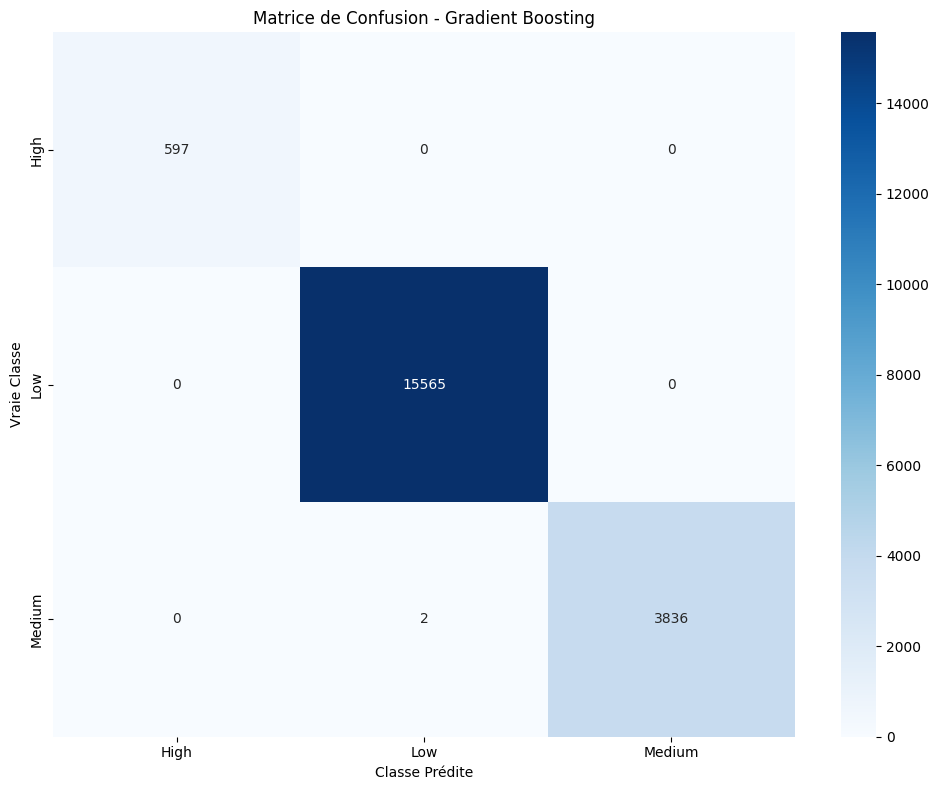

In [70]:
# ====================================================================
# ÉTAPE 7: COMPARAISON DES MODÈLES
# ====================================================================
print("\n[ÉTAPE 7] COMPARAISON DES MODÈLES")
print("-"*70)

comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Accuracy Test': [results[m]['acc_test'] for m in results.keys()],
    'F1-Score Test': [results[m]['f1_test'] for m in results.keys()]
})

print("\n", comparison_df.to_string(index=False))

# Sélectionner le meilleur modèle
best_model_name = comparison_df.loc[comparison_df['F1-Score Test'].idxmax(), 'Modèle']
best_model_info = results[best_model_name]

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   F1-Score: {best_model_info['f1_test']:.4f}")

# ====================================================================
# ÉTAPE 8: ANALYSE DÉTAILLÉE DU MEILLEUR MODÈLE
# ====================================================================
print("\n[ÉTAPE 8] ANALYSE DÉTAILLÉE DU MEILLEUR MODÈLE")
print("-"*70)

print(f"\nRapport de classification complet:")
print(classification_report(y_test, best_model_info['y_pred']))

# Matrice de confusion
cm = confusion_matrix(y_test, best_model_info['y_pred'])
print(f"\nMatrice de confusion:")
print(cm)

# Visualisation de la matrice de confusion
plt.figure(figsize=(10, 8))
classes = sorted(y.unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title(f'Matrice de Confusion - {best_model_name}')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/confusion_matrix_final.png', dpi=150)
print("\n✓ Matrice de confusion sauvegardée")



[ÉTAPE 9] IMPORTANCE DES FEATURES
----------------------------------------------------------------------

Top 10 features les plus importantes:
                      Feature   Importance
                 Error_Rate_% 5.515030e-01
Production_Speed_units_per_hr 4.484970e-01
         Power_Consumption_kW 2.575595e-13
           Network_Latency_ms 7.405868e-14
                Temperature_C 6.072042e-14
 Predictive_Maintenance_Score 2.724920e-14
                Packet_Loss_% 2.249593e-14
Quality_Control_Defect_Rate_% 2.231597e-14
                 Vibration_Hz 8.860834e-15
                   Machine_ID 0.000000e+00
✓ Graphique d'importance sauvegardé

[ÉTAPE 10] VALIDATION CROISÉE
----------------------------------------------------------------------
Validation croisée en cours (5 folds)...

Scores par fold: [0.99974987 1.         1.         1.         1.        ]
Moyenne: 0.9999 (+/- 0.0002)

[ÉTAPE 11] DIAGNOSTIC FINAL
----------------------------------------------------------------------

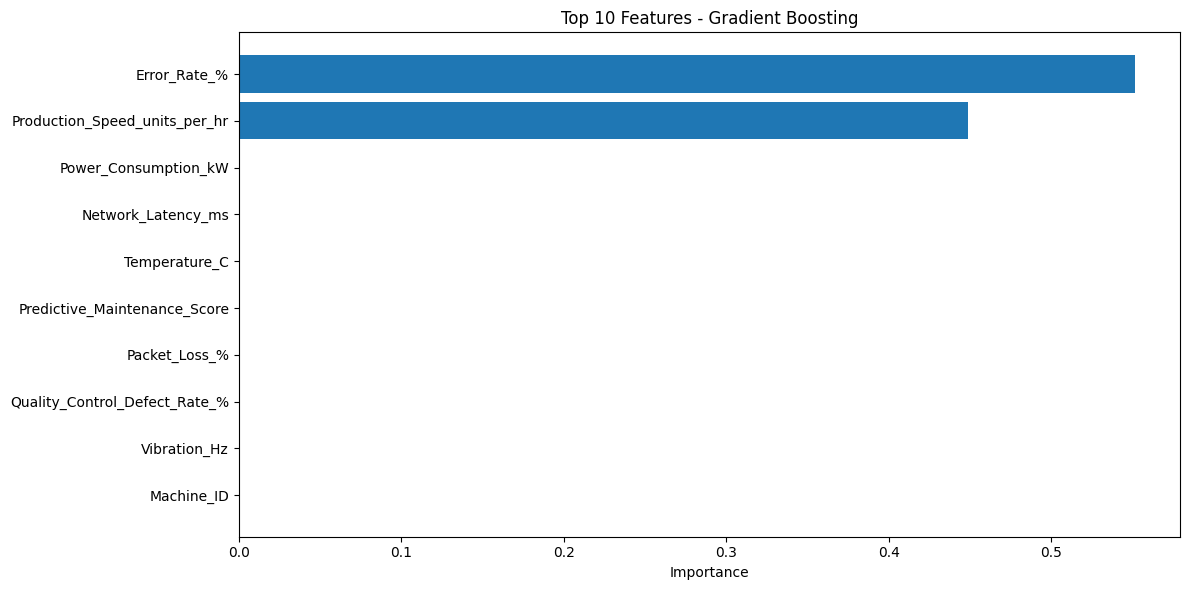

In [72]:
# ====================================================================
# ÉTAPE 9: IMPORTANCE DES FEATURES
# ====================================================================
print("\n[ÉTAPE 9] IMPORTANCE DES FEATURES")
print("-"*70)

# Extraire l'importance des features
if hasattr(best_model_info['model'], 'feature_importances_'):
    importances = best_model_info['model'].feature_importances_
elif hasattr(best_model_info['model'], 'named_steps'):
    # Pour les pipelines
    importances = best_model_info['model'].named_steps['model'].feature_importances_
else:
    print("⚠️ Ce modèle ne fournit pas d'importance de features")
    importances = None

if importances is not None:
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 features les plus importantes:")
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Visualisation
    plt.figure(figsize=(12, 6))
    top_n = min(15, len(feature_importance_df))
    plt.barh(range(top_n), 
             feature_importance_df['Importance'].head(top_n))
    plt.yticks(range(top_n), 
               feature_importance_df['Feature'].head(top_n))
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    #plt.savefig('/mnt/user-data/outputs/feature_importance_final.png', dpi=150)
    print("✓ Graphique d'importance sauvegardé")

# ====================================================================
# ÉTAPE 10: VALIDATION CROISÉE
# ====================================================================
print("\n[ÉTAPE 10] VALIDATION CROISÉE")
print("-"*70)

print("Validation croisée en cours (5 folds)...")
cv_scores = cross_val_score(
    best_model_info['model'],
    X_train, y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

print(f"\nScores par fold: {cv_scores}")
print(f"Moyenne: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ====================================================================
# ÉTAPE 11: DIAGNOSTIC FINAL
# ====================================================================
print("\n[ÉTAPE 11] DIAGNOSTIC FINAL")
print("-"*70)

diagnostics = []

# Check 1: Scores parfaits?
if acc_test_rf >= 0.99:
    diagnostics.append("⚠️ ATTENTION: Scores trop parfaits! Data leakage possible!")
else:
    diagnostics.append("✓ Scores réalistes")

# Check 2: Overfitting?
if 'acc_train' in best_model_info:
    gap = abs(best_model_info['acc_train'] - best_model_info['acc_test'])
    if gap > 0.15:
        diagnostics.append(f"⚠️ Overfitting détecté (gap: {gap:.4f})")
    else:
        diagnostics.append(f"✓ Pas d'overfitting majeur (gap: {gap:.4f})")

# Check 3: Déséquilibre géré?
if imbalance_ratio > 3:
    diagnostics.append("✓ Déséquilibre géré avec class_weight='balanced'")

# Check 4: Cohérence train/test distribution?
diagnostics.append("✓ Split stratifié utilisé")

print("\nRésultat des diagnostics:")
for diag in diagnostics:
    print(f"  {diag}")

# ====================================================================
# RÉSUMÉ FINAL
# ====================================================================
print("\n" + "="*70)
print("RÉSUMÉ FINAL")
print("="*70)

print(f"""
Dataset:
  - Total: {len(df)} exemples
  - Features: {len(feature_cols)}
  - Classes: {len(y.unique())} ({', '.join(sorted(y.unique()))})
  - Train: {len(X_train)} exemples
  - Test: {len(X_test)} exemples

Meilleur Modèle: {best_model_name}
  - Accuracy Test: {best_model_info['acc_test']:.4f}
  - F1-Score Test: {best_model_info['f1_test']:.4f}
  - CV Score (mean): {cv_scores.mean():.4f}

Fichiers créés:
  - confusion_matrix_final.png
  - feature_importance_final.png

Bonnes pratiques respectées:
  ✓ Split stratifié
  ✓ Pas de data leakage (fit sur train uniquement)
  ✓ Gestion du déséquilibre (class_weight='balanced')
  ✓ Validation croisée effectuée
  ✓ Analyse des features importantes
""")

if acc_test_rf >= 0.99:
    print("""
⚠️ ⚠️ ⚠️ ALERTE DATA LEAKAGE POSSIBLE ⚠️ ⚠️ ⚠️

Vos scores sont trop parfaits! Vérifiez:
1. Qu'aucune feature ne contient directement la target
2. Les corrélations > 0.9 identifiées plus haut
3. Que vous n'avez pas de duplicatas
4. Que le split est bien aléatoire (pas temporel séquentiel)

Lancez le script diagnostic_leakage.py pour plus de détails.
""")

print("\n" + "="*70)
print("PIPELINE TERMINÉ AVEC SUCCÈS!")
print("="*70)